# Bunch compressor geometry

In [1]:
%pylab --no-import-all inline

Populating the interactive namespace from numpy and matplotlib


In [2]:
THIS_NOTEBOOK = '$LCLS_LATTICE/bmad/overlays/cu/source/bunch_compressors.ipynb'

In [3]:
from scipy import optimize

In [4]:
def theta_for_chicane(x, Lbp, Ldp):
    """
    Returns the exact angle required to provide a total trasverse offset x
    for a symmetric theta_for_chicane by inverting:

    x = -2 * Lbp *tan(theta/2) - Ldp * tan(theta)

    Parameters
    ----------
    x : float
        Total offset desired
    Lbp: float
        Projected bend length
    Ldp: float
        Projected drift length
        
        
    Examples
    --------
    The LCLS BC1 at SLAC has nominal parameters:
    
        bc1_theta_default = -0.093583513589 
        bc1_Lp_default = 0.2032
        bc1_Lp_drift_default = 2.4349 
    
    which corresponds to an x_offset = 0.24756410510692992
    
    This will return that angle:
        theta_for_chicane(0.24756410510692992 , bc1_Lp_default, bc1_Lp_drift_default)
    
    """
    
    f = lambda theta:  -2 * Lbp *np.tan(theta/2) - Ldp * np.tan(theta) - x
    
    sol = optimize.root_scalar(f, bracket=[-1, 1], method='brentq')
    
    return sol.root


#bc1_theta_default = -0.093583513589 
#bc1_Lp_default = 0.2032
#bc1_Lp_drift_default = 2.4349 
#theta_for_chicane(0.24756410510692992 , bc1_Lp_default, bc1_Lp_drift_default)

In [5]:
!pwd

/Users/chrisonian/Code/GitHub/lcls-lattice/bmad/overlays/cu/source


In [6]:
def offset_overlay(name, control, var, x, y, default):
    """
    Makes an overlay with knot points for spline interpolation
    """
    X = '! Automatically generated interpolation points using:\n'
    X += f'! {THIS_NOTEBOOK}\n'
    X += f'{name}: overlay = {{{control}: {{'
    X +=  np.array2string(y, separator=',')[1:-1]
    X += '}},\n '
    X += f'var={{{var}}}, \n x_knot = {{'+np.array2string(x, separator=',')[1:-1] + '}'
    X += '\n'
    X+=f'{name}[{var}] = {default}'
    return X

## BC1

In [7]:
bc1_theta_default = -0.093583513589   # AB11! Same as AB11 =  !full chicane bend angle (rad)
bc1_Lp_default = 0.2032
bc1_Lp_drift_default = 2.4349 
bc1_offset_default = 2.47542378E-01

In [8]:
theta_for_chicane(bc1_offset_default, bc1_Lp_default, bc1_Lp_drift_default)

-0.0935753454831188

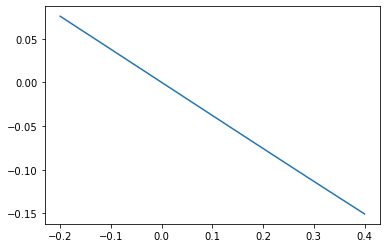

In [9]:
xlist = np.linspace(-.2, 0.4, 10)
angles = np.array([theta_for_chicane(x , bc1_Lp_default, bc1_Lp_drift_default) for x in xlist])
plt.plot(xlist, angles)

In [10]:
print(offset_overlay('O_BC1_offset', 'O_BC1[angle_deg]', 'offset', xlist, angles*180/np.pi, bc1_offset_default))

! Automatically generated interpolation points using:
! $LCLS_LATTICE/bmad/overlays/cu/source/bunch_compressors.ipynb
O_BC1_offset: overlay = {O_BC1[angle_deg]: { 4.33589907, 2.89349031, 1.44761486, 0.        ,-1.44761486,-2.89349031,
 -4.33589907,-5.77313792,-7.20353921,-8.6254818 }},
 var={offset}, 
 x_knot = {-2.00000000e-01,-1.33333333e-01,-6.66666667e-02, 2.77555756e-17,
  6.66666667e-02, 1.33333333e-01, 2.00000000e-01, 2.66666667e-01,
  3.33333333e-01, 4.00000000e-01}
O_BC1_offset[offset] = 0.247542378


## BC2

In [11]:
bc2_theta_default =  -0.036971268085 
bc2_Lp_default = 0.549
bc2_Lp_drift_default = 9.8602

bc2_offset_default = 3.85010405E-01

In [12]:
theta_for_chicane(bc2_offset_default, bc2_Lp_default, bc2_Lp_drift_default)

-0.03697132399340232

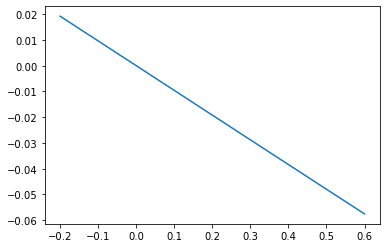

In [13]:
xlist2 = np.linspace(-.2, 0.6, 13)
angles2 = np.array([theta_for_chicane(x , bc2_Lp_default, bc2_Lp_drift_default) for x in xlist2])
plt.plot(xlist2, angles2)

In [14]:
print(offset_overlay('O_BC2_offset', 'O_BC2[angle_deg]', 'offset', xlist2, angles2*180/np.pi, bc2_offset_default))

! Automatically generated interpolation points using:
! $LCLS_LATTICE/bmad/overlays/cu/source/bunch_compressors.ipynb
O_BC2_offset: overlay = {O_BC2[angle_deg]: { 1.10073799, 0.7338735 , 0.3669512 , 0.        ,-0.3669512 ,-0.7338735 ,
 -1.10073799,-1.4675158 ,-1.8341781 ,-2.20069612,-2.56704115,-2.93318456,
 -3.29909781}},
 var={offset}, 
 x_knot = {-0.2       ,-0.13333333,-0.06666667, 0.        , 0.06666667, 0.13333333,
  0.2       , 0.26666667, 0.33333333, 0.4       , 0.46666667, 0.53333333,
  0.6       }
O_BC2_offset[offset] = 0.385010405
